Tableau de données :
  Individu  Taille  Poids  Age  Revenu
0     Ind1     175     70   25      35
1     Ind2     168     65   30      45
2     Ind3     180     80   35      50
3     Ind4     165     60   28      30
4     Ind5     170     75   40      55
5     Ind6     185     90   45      60
6     Ind7     160     55   22      25
7     Ind8     172     72   33      48
8     Ind9     178     78   38      52
9    Ind10     162     58   26      28

Valeurs propres : [4.06157288 0.31924712 0.05664283 0.00698161]

Variance expliquée par composante : [0.9138539  0.0718306  0.01274464 0.00157086]
Variance expliquée cumulative : [0.9138539  0.9856845  0.99842914 1.        ]


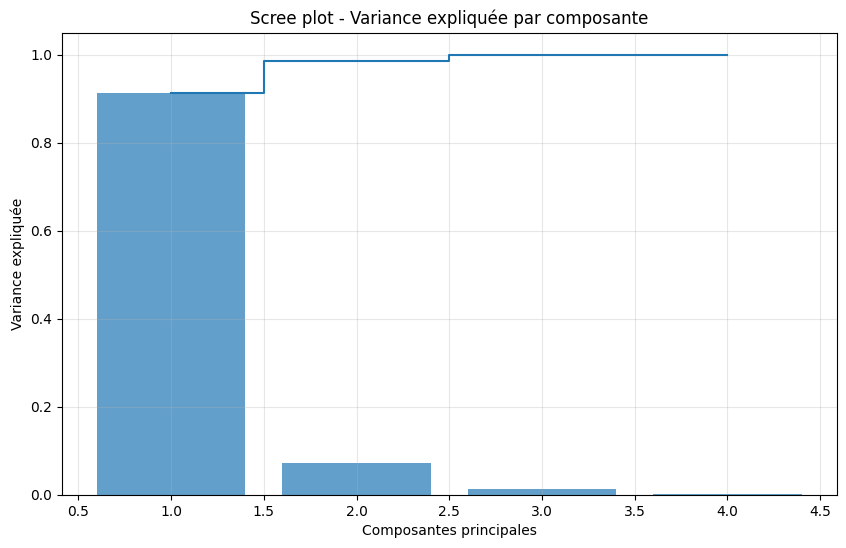

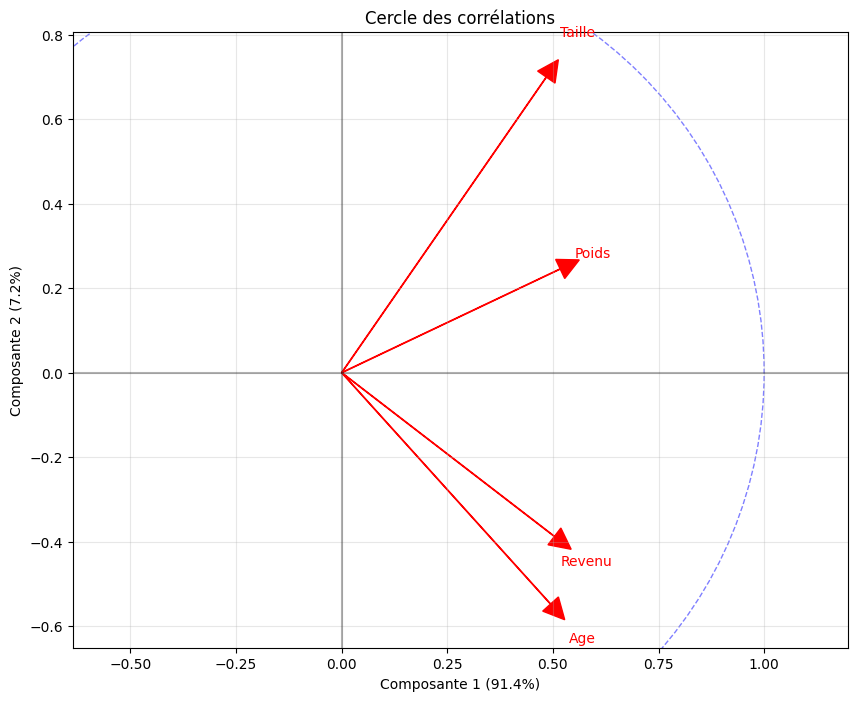

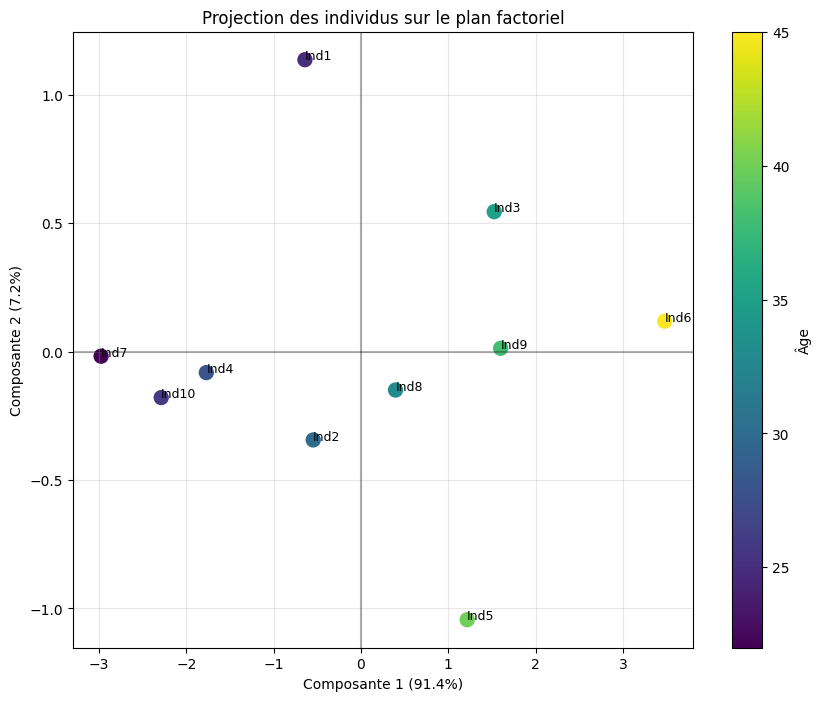

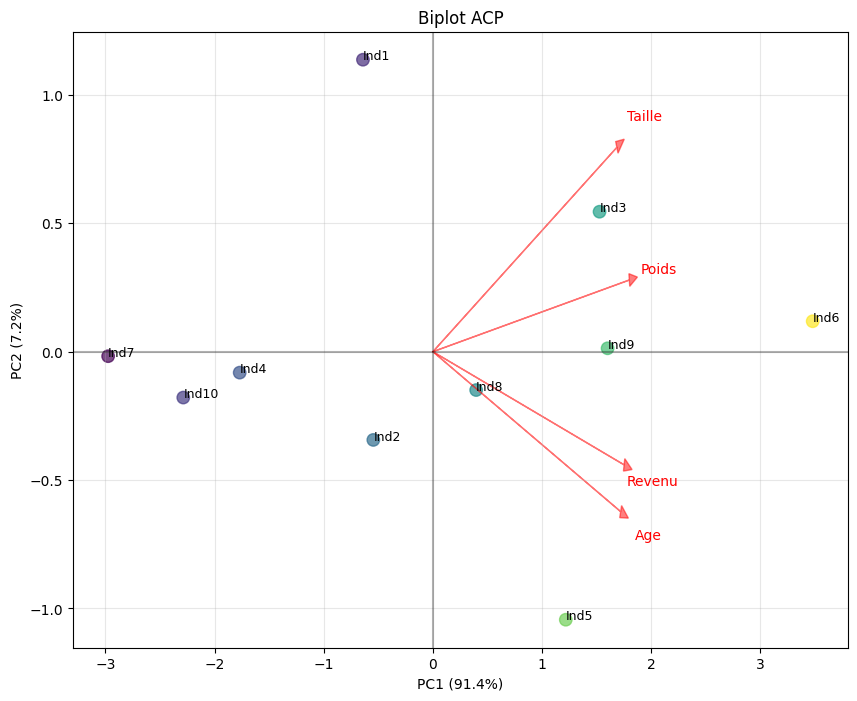


Nombre de composantes nécessaires pour 80% de variance :
1 composantes expliquent 91.4% de la variance

Matrice des composantes (loadings) :
             PC1       PC2       PC3       PC4
Taille  0.484359  0.699714 -0.020460 -0.524764
Poids   0.517176  0.245506 -0.128800  0.809732
Age     0.494366 -0.547655 -0.627245 -0.249479
Revenu  0.503515 -0.387557  0.767825 -0.081955


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Création du jeu de données
donnees = pd.DataFrame({
    'Individu': ['Ind1', 'Ind2', 'Ind3', 'Ind4', 'Ind5',
                 'Ind6', 'Ind7', 'Ind8', 'Ind9', 'Ind10'],
    'Taille': [175, 168, 180, 165, 170, 185, 160, 172, 178, 162],
    'Poids': [70, 65, 80, 60, 75, 90, 55, 72, 78, 58],
    'Age': [25, 30, 35, 28, 40, 45, 22, 33, 38, 26],
    'Revenu': [35, 45, 50, 30, 55, 60, 25, 48, 52, 28]
})

print("Tableau de données :")
print(donnees)

# Préparation des données (variables quantitatives seulement)
X = donnees[['Taille', 'Poids', 'Age', 'Revenu']]

# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Application de l’ACP
acp = PCA()
X_acp = acp.fit_transform(X_scaled)

# Valeurs propres et pourcentage de variance
valeurs_propres = acp.explained_variance_
print(f"\nValeurs propres : {valeurs_propres}")

# Variance expliquée
variance_expliquee = acp.explained_variance_ratio_
print(f"\nVariance expliquée par composante : {variance_expliquee}")
print(f"Variance expliquée cumulative : {np.cumsum(variance_expliquee)}")

# Scree plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(variance_expliquee) + 1),
        variance_expliquee, alpha=0.7, align='center')
plt.step(range(1, len(variance_expliquee) + 1),
         np.cumsum(variance_expliquee), where='mid')
plt.xlabel('Composantes principales')
plt.ylabel('Variance expliquée')
plt.title('Scree plot - Variance expliquée par composante')
plt.grid(True, alpha=0.3)
plt.show()

# Cercle des corrélations
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(len(acp.components_[0])):
    ax.arrow(0, 0,
             acp.components_[0, i],
             acp.components_[1, i],
             head_width=0.05, head_length=0.05,
             fc='r', ec='r')
    ax.text(acp.components_[0, i] * 1.15,
            acp.components_[1, i] * 1.15,
            X.columns[i], color='r',
            ha='center', va='center')

# Cercle unité
circle = plt.Circle((0, 0), 1, fill=False,
                    color='blue', linestyle='--', alpha=0.5)
ax.add_artist(circle)

# Configuration du graphique
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel(f'Composante 1 ({variance_expliquee[0]*100:.1f}%)')
plt.ylabel(f'Composante 2 ({variance_expliquee[1]*100:.1f}%)')
plt.title('Cercle des corrélations')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# Projection des individus
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_acp[:, 0], X_acp[:, 1],
                      c=donnees['Age'],
                      cmap='viridis', s=100)

for i, txt in enumerate(donnees['Individu']):
    plt.annotate(txt, (X_acp[i, 0], X_acp[i, 1]), fontsize=9)

plt.colorbar(scatter, label='Âge')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel(f'Composante 1 ({variance_expliquee[0]*100:.1f}%)')
plt.ylabel(f'Composante 2 ({variance_expliquee[1]*100:.1f}%)')
plt.title('Projection des individus sur le plan factoriel')
plt.grid(True, alpha=0.3)
plt.show()

# Biplot
def biplot(score, coeff, labels=None):
    plt.figure(figsize=(10, 8))
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]

    # Individus
    plt.scatter(xs, ys, c=donnees['Age'],
                cmap='viridis', s=80, alpha=0.7)

    for i, txt in enumerate(donnees['Individu']):
        plt.annotate(txt, (xs[i], ys[i]), fontsize=9)

    # Variables
    for i in range(n):
        plt.arrow(0, 0,
                  coeff[i, 0] * max(xs),
                  coeff[i, 1] * max(ys),
                  color='r', alpha=0.5, head_width=0.05)

        if labels is None:
            plt.text(coeff[i, 0] * max(xs) * 1.15,
                     coeff[i, 1] * max(ys) * 1.15,
                     f"Var {i+1}", color='r',
                     ha='center', va='center')
        else:
            plt.text(coeff[i, 0] * max(xs) * 1.15,
                     coeff[i, 1] * max(ys) * 1.15,
                     labels[i], color='r',
                     ha='center', va='center')

    plt.xlabel(f'PC1 ({variance_expliquee[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({variance_expliquee[1]*100:.1f}%)')
    plt.title('Biplot ACP')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.show()

biplot(X_acp, acp.components_.T, X.columns)

# Analyse des résultats
print("\nNombre de composantes nécessaires pour 80% de variance :")
cumsum = np.cumsum(variance_expliquee)

for i, cum in enumerate(cumsum):
    if cum >= 0.8:
        print(f"{i+1} composantes expliquent {cum*100:.1f}% de la variance")
        break

print("\nMatrice des composantes (loadings) :")
loadings = pd.DataFrame(acp.components_.T,
                        columns=[f'PC{i+1}' for i in range(acp.n_components_)],
                        index=X.columns)
print(loadings)
